# 1.2.0_b

该jupter notebook 对应1.2.0 版本，但面向实施，不记录历史版本

计划步骤

## backgroud
 实现根据chunk元数据进行对应，有目标的抽取
1. 读取的是目录下的markdown文件而不是pdf文件
2. 通过AI Agent获取markdown文件对应的metadata信息，为document对象进行赋值，并自动继承给其对应的每一个chunk（node）
    * 需要对代码块A中load_markdown_with_headers函数进行修改，添加metadata信息
    * 定义外部AI Agent，用于获取metadata信息
    * 该AI Agent 可以被load_markdown_with_headers 函数调用，整体框架中
3. 实现chunk 的语义化标签识别，比如Methods，Results，Discussion等
4. 实现对schema中三元组关系，以及主谓宾prompt的循环抽取，直到所有关系都被抽取出来，提升查全率
5. 在循环关系中实现chunk的对应label抽取，提升查准率

## 更新日志

* 20251110
1. 抽取时必须加入元数据，参考dc 核心元数据，目标是最终的neo4j 中的对应节点（特别是chunk节点）都包含这些元数据。从而能够溯源，并支持支持同一个paper 内的分析。
2. relation目前抽取时，没有保留原始文本信息，对照node具有WHU_HASORIGINALTEXT属性，缺少WHU_HASORIGINALTEXT属性，导致后期分析问题，故必须为relation补全这一属性。
3. scheam定义中缺少
   - Method-[supports]->data
   - Statement-[supports]->Claim
   特别是Statement-[supports]->Claim非常重要，必须补全
4. 同时抽取中relation缺乏属性，包括weight，导致后期的路径，dependency等计算意义减弱，但如何定义weight，需要与实际的论文关系结合例如，整个kg中，activity与method的重复次数，在此使用多种方法来确定
   - 直接通过llm 来确定，其在抽取过程中就确定weight，但具有不稳定下
   - kg构建完成后，通过运算确定权重，例如，重复次数，路径长度等。这种方法具有可重复性，可解释的优点
   最终的weight，可以定义多个，包括llm_weihgt, math_weight, 根据需要进行选择



 


# A chunk 构建

 

## A 1. backgournd


代码块A，实现md 读取，切分，兼容自定义spllier 类定义，以及自定义的chunk 标签设置
实现现md文件读取以及chunk对应标签的设置
``` mermaid
graph TD
    A[开始：学术文档处理] --> B[加载Markdown文档]
    B --> C[parse_markdown_headers<br/>解析标题结构]
    C --> D[构建位置->标题映射表]
    
    B --> E[split_by_markdown_structure<br/>智能文档分割]
    E --> F[按标题和段落边界分割]
    F --> G[create_clean_nodes_from_document<br/>创建文本节点]
    
    D --> H[find_node_position<br/>定位节点位置]
    G --> H
    H --> I[assign_header_to_node<br/>分配标题路径]
    I --> J[add_header_paths_to_nodes<br/>批量添加标题路径]
    
    J --> K{是否需要语义分类?}
    K -->|是| L[SafeSemanticSplitterNodeParser<br/>安全语义分割器]
    K -->|否| S[输出最终节点]
    
    L --> M[get_nodes_from_documents<br/>获取节点]
    M --> N[父类语义分割]
    N --> O{是否有LLM推断器?}
    
    O -->|否| S
    O -->|是| P[setup_llm_and_inferrer<br/>设置LLM推断器]
    P --> Q[infer_section_role_llm<br/>推断学术角色]
    
    Q --> R[分类决策逻辑]
    R --> T[Title/Abstract/Introduction<br/>Methods/Results/Discussion<br/>Conclusion/References等]
    T --> U[增强节点元数据]
    U --> S
    
    S --> V[完成：结构化学术文档节点]
    
  style A fill:#e1f5fe
    style V fill:#c8e6c9
    style L fill:#fff3e0
    style Q fill:#fce4ec

```

    
``` mermaid
graph TD
    subgraph "文档加载模块"
        B1[load_markdown_with_headers]
        B1 --> B2[遍历.md文件]
        B2 --> B3[读取文件内容]
        B3 --> B4[创建Document对象]
    end
    
    subgraph "位置匹配算法"
        H1[多长度文本匹配]
        H1 --> H2[200/100/50字符匹配]
        H2 --> H3[句子级匹配]
        H3 --> H4[返回最佳位置]
    end
    
    subgraph "LLM分类系统"
        Q1[构建提示词]
        Q1 --> Q2[DoCO标准分类]
        Q2 --> Q3[HeaderPath + Text分析]
        Q3 --> Q4[返回单一标签]
    end
    
  
    ```

## A 2. MD 读取划分主程序

In [9]:
from typing import List, Optional, Callable
from llama_index.core import Document
from llama_index.core.node_parser import SemanticSplitterNodeParser, SimpleNodeParser
from llama_index.core.schema import BaseNode, TextNode
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
import os
import re
import nest_asyncio
# 解决异步事件循环问题
nest_asyncio.apply()

def parse_markdown_headers(text: str) -> dict:
    """解析Markdown文本中的标题层级结构"""
    lines = text.split('\n')
    position_to_header = {}
    header_stack = []
    char_position = 0
    
    for line in lines:
        if line.strip().startswith('#'):
            level = len(line) - len(line.lstrip('#'))
            title = line.lstrip('#').strip()
            
            # 维护标题栈
            header_stack = [h for h in header_stack if h[0] < level]
            header_stack.append((level, title))
            
            # 构建header_path
            header_path = ' > '.join([h[1] for h in header_stack])
            position_to_header[char_position] = header_path
        
        char_position += len(line) + 1
    
    return position_to_header

def split_by_markdown_structure(text: str, chunk_size: int = 1000) -> List[str]:
    """根据Markdown结构进行文档分割，避免表格摘要生成"""
    lines = text.split('\n')
    chunks = []
    current_chunk = []
    current_size = 0
    
    for line in lines:
        line_size = len(line) + 1  # +1 for \n
        
        # 如果遇到新的标题且当前chunk不为空，则分割
        if (line.strip().startswith('#') and current_chunk and current_size > 200):
            chunks.append('\n'.join(current_chunk))
            current_chunk = [line]
            current_size = line_size
        else:
            current_chunk.append(line)
            current_size += line_size
            
            # 如果chunk太大，在合适的地方分割
            if current_size > chunk_size:
                # 寻找合适的分割点（段落结束）
                if line.strip() == '':
                    chunks.append('\n'.join(current_chunk[:-1]))
                    current_chunk = []
                    current_size = 0
    
    # 添加最后一个chunk
    if current_chunk:
        chunks.append('\n'.join(current_chunk))
    
    return chunks

def create_clean_nodes_from_document(doc: Document) -> List[TextNode]:
    """从文档创建干净的节点，不生成表格摘要"""
    text_chunks = split_by_markdown_structure(doc.text, chunk_size=800)
    nodes = []
    
    for i, chunk in enumerate(text_chunks):
        if chunk.strip():  # 只处理非空chunk
            node = TextNode(
                text=chunk,
                metadata={
                    'filename': doc.metadata.get('filename', ''),
                    'chunk_id': i
                }
            )
            nodes.append(node)
    
    return nodes

def find_node_position(original_text: str, node_text: str) -> int:
    """定位节点在原文中的位置"""
    # 清理文本，去除多余空白
    clean_node = re.sub(r'\s+', ' ', node_text.strip())
    clean_original = re.sub(r'\s+', ' ', original_text)
    
    # 尝试多种匹配方式
    for length in [200, 100, 50]:
        if len(clean_node) >= length:
            pos = clean_original.find(clean_node[:length])
            if pos >= 0:
                return pos
    
    # 尝试匹配第一句话
    sentences = clean_node.split('.')
    if sentences and len(sentences[0].strip()) > 10:
        pos = clean_original.find(sentences[0].strip())
        if pos >= 0:
            return pos
    
    return -1

def assign_header_to_node(node: BaseNode, original_text: str, position_to_header: dict, default_title: str):
    """为单个节点分配header_path"""
    if not isinstance(node, TextNode):
        return
    
    if node.metadata is None:
        node.metadata = {}
    
    if not position_to_header:
        node.metadata['header_path'] = default_title
        return
    
    node_text = node.get_content()
    node_start = find_node_position(original_text, node_text)
    
    if node_start >= 0:
        # 找到最近的上级标题
        best_header = ""
        best_position = -1
        
        for pos, header in position_to_header.items():
            if pos <= node_start and pos > best_position:
                best_header = header
                best_position = pos
        
        node.metadata['header_path'] = best_header or default_title
    else:
        node.metadata['header_path'] = default_title

def add_header_paths_to_nodes(nodes: List[BaseNode], original_text: str) -> List[BaseNode]:
    """为节点添加header_path信息"""
    position_to_header = parse_markdown_headers(original_text)
    
    # 提取默认标题
    lines = original_text.split('\n')
    default_title = "Unknown"
    for line in lines[:20]:
        stripped = line.strip()
        if stripped.startswith('#'):
            default_title = stripped.lstrip('#').strip()
            break
    
    # 为每个节点分配header_path
    for node in nodes:
        assign_header_to_node(node, original_text, position_to_header, default_title)
    
    return nodes

def load_markdown_with_headers(directory_path: str) -> List[Document]:
    """加载Markdown文件"""
    documents = []
    
    for filename in os.listdir(directory_path):
        if filename.endswith('.md'):
            file_path = os.path.join(directory_path, filename)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            doc = Document(text=content, metadata={'filename': filename})# 对该metadata进行扩充，融合dc核心元数据要求的元素
            documents.append(doc)
    
    return documents
 
########兼容子类的定义#####################################
class SafeSemanticSplitterNodeParser(SemanticSplitterNodeParser):
    """安全的语义分割器，避免异步问题"""
    
    def __init__(
        self,
        embed_model=None,
        similarity_threshold: float = 0.72,
        window_size: int = 2,
        chunk_size: int = 300,
        section_role_inferrer: Optional[Callable[[str, str], str]] = None,
        **kwargs
    ):
        if embed_model is None:
            embed_model = HuggingFaceEmbedding(model_name="maidalun1020/bce-embedding-base_v1")
        
        super().__init__(
            embed_model=embed_model,
            similarity_threshold=similarity_threshold,
            window_size=window_size,
            chunk_size=chunk_size,
            **kwargs
        )
        
        # 使用object.__setattr__来绕过Pydantic的字段验证
        object.__setattr__(self, '_section_role_inferrer', section_role_inferrer)
    
    def get_nodes_from_documents(
        self, 
        documents: List[Document], 
        show_progress: bool = False,
        **kwargs
    ) -> List[BaseNode]:
        
        # 执行语义分割
        nodes = super().get_nodes_from_documents(documents, show_progress=show_progress, **kwargs)
        
        # 如果没有section_role_inferrer，直接返回
        section_role_inferrer = getattr(self, '_section_role_inferrer', None)
        if not section_role_inferrer:
            return nodes
        
        # 添加section_role
        enhanced_nodes = []
        for node in nodes:
            if isinstance(node, TextNode):
                node_text = node.get_content()
                original_metadata = node.metadata or {}
                header_path = original_metadata.get("header_path", "")
                
                # 只在没有section_role时才推断
                if "section_role" not in original_metadata:
                    try:
                        section_role = section_role_inferrer(node_text, header_path)
                        # 创建新的metadata字典
                        enhanced_metadata = dict(original_metadata)
                        enhanced_metadata["section_role"] = section_role
                        node.metadata = enhanced_metadata
                    except Exception as e:
                        print(f"推断section_role失败: {e}")
            
            enhanced_nodes.append(node)
        
        return enhanced_nodes

def setup_llm_and_inferrer(llm=None):
    """设置LLM和推断函数"""
    try:
        from llama_index.core import Settings
        from llama_index.core.llms import ChatMessage, MessageRole
        from llama_index.llms.deepseek import DeepSeek
        
        # 检查是否已经设置了LLM
      
        
        def infer_section_role_llm(text: str, header_path: str) -> str:
            prompt = f"""


## System

======

You classify a scientific article chunk into **DoCO-style section roles**.  
Analyze **HeaderPath** and **Text** and return **exactly one** label from AllowedLabels.
Inputs
======

* **HeaderPath**: `{header_path}` _(full breadcrumb like “1 Introduction > 1.1 Study aims”)_

* **Text** (truncated to 1200 chars): `{text[:1200]}`

### AllowedLabels (choose exactly one; do not invent new ones)

==========================================================

`Title | Abstract | Author | Introduction | Review | Methods_Materials | Experiment | Results | Discussion | Conclusion | References | Acknowledgments | Other`

## Core Task

=========

Read **HeaderPath** and **Text**. Output the **single best** label.
Decision Order (strict)
=======================

1. **Hard Header Match (strong signals)** → assign directly unless Text _clearly contradicts_.

2. **Content Cues (lexical/semantic patterns)** → if no hard match or header is mixed.

3. **Tie-break & Mixed Headers** (“Results and Discussion”, “Methods and Results”):
   
   * If one section’s **content cues dominate** (≥2 strong cues vs. ≤1 other), choose that one.
   
   * Otherwise use **first role named in the header**.

4. If still unclear/administrative/non-scholarly → **Other**.

### Hard Header Match: Synonyms / Multilingual Keys

===============================================

_(match header tokens case-insensitively; Chinese included)_

* **Title**: `title`, `article title`, `题目`, `标题`

* **Abstract**: `abstract`, `summary`, `概述`, `摘要`, `提要`

* **Author**: `authors`, `author information`, `作者`, `作者信息`, `通信作者`, `affiliations`

* **Introduction**: `introduction`, `background`, `绪论`, `前言`, `研究背景`

* **Review**: `related work`, `literature review`, `综述`, `文献回顾`, `研究进展`

* **Methods_Materials**: `methods`, `materials`, `materials and methods`, `methodology`,  
  `study area`, `site description`, `sampling strategy`, `数据与方法`, `材料与方法`, `研究区域`, `采样方法`, `实验材料`

* **Experiment**: `experiment`, `experimental procedure/setup`, `试验`, `实验过程`, `实验步骤`, `实验装置`

* **Results**: `results`, `findings`, `结果`, `实验结果`, `研究结果`

* **Discussion**: `discussion`, `discussions`, `讨论`

* **Conclusion**: `conclusion`, `conclusions`, `总结`, `结论`

* **References**: `references`, `bibliography`, `参考文献`

* **Acknowledgments**: `acknowledgments`, `acknowledgements`, `funding`, `致谢`, `基金资助`

* **Other**: `appendix`, `supplementary`, `附录`, `补充材料`, figure/table lists, TOC

### Content Cues (when header alone is insufficient)

================================================

* **Title**: very short; often only the paper name; no sentences; capitalization pattern; no citations.

* **Abstract**: mini-IMRaD signals in one block (Background/Methods/Results/Conclusions), study aims + key numeric outcomes.

* **Author**: author names, affiliations, emails, ORCID, department, correspondence footnotes.

* **Introduction**: problem context, gap/aims, hypotheses, citations density high; _no procedural details_.

* **Review**: survey tone across many sources, taxonomy/comparison tables, phrases like “we summarize/overview…”.

* **Methods_Materials**: reproducible setup without reporting _this run’s_ outcomes; materials specs (purity %, catalog #), **study area/site**, permits/ethics, sampling design, instrument models, statistical plans, code/data availability statements when posed as pre-analysis setup.

* **Experiment**: **procedural execution** with stepwise verbs and parameters for a _specific run_: “we added/heated/incubated…”, concrete **time–temp–dose–device** triples, randomized allocation, inclusion/exclusion, intervention protocols; may include inline sanity-check numbers but **no full results narrative**.

* **Results**: objective findings, tables/figures refs, **p-values/CI/effect sizes**, “increase/decrease”, “significant at p<…”, point estimates, CIs.

* **Discussion**: interpretation, mechanisms, compare-and-contrast with prior work, limitations, implications, generalizability.

* **Conclusion**: brief take-home message, contributions, future work, policy/clinical/environmental recommendations.

* **References**: citation lists, numbered or author-year entries, DOI/URL heavy, no prose.

* **Acknowledgments**: funding numbers, grant agencies, thanks to individuals, IRB/permit numbers when in a gratitude context.

### Domain-Specific Overrides (环境/医学/化学常见)

======================================

* **Study Area / Site Description / Sampling** → **Methods_Materials**

* **Ethics / IRB / Permits**:
  
  * If part of setup description → **Methods_Materials**
  
  * If only gratitude/funding context → **Acknowledgments**

* **“Experimental Section”** (化学期刊常用):
  
  * If mainly reagents/setup/specs → **Methods_Materials**
  
  * If step-by-step execution details dominate → **Experiment**

* **“Results and Discussion”**：按“内容 cues 主导”规则判定；难分则取 **Results**（先出现者）。

### Noise Handling

==============

* Ignore page furniture: running headers/footers, figure captions, table of contents, copyright.

* If **HeaderPath** contradicts in-text signals, trust **Text** when ≥2 strong content cues disagree with header.

## Output

======

Return **exactly one** label string. **No explanations.**
Few-Shot Examples
=================

Input → Output

* `Header: Materials and Methods — Study Area and Sampling` → `Methods_Materials`

* `Header: Experimental Procedure` + text shows “heated at 95 °C for 10 min; centrifuged 12,000 rpm; n=30” → `Experiment`

* `Header: Results and Discussion` + text dominated by p-values/effect sizes → `Results`

* `Header: Related Work` + survey narrative → `Review`

* `Header: Acknowledgments — Funding` + grant numbers → `Acknowledgments`

* `Header: Data and Code Availability` + repository links as pre-analysis setup → `Methods_Materials`

* `Header: —` + a numbered bibliography list → `References`

* `Header: General Information` + admin content → `Other`
"""
            try:
                resp = llm.chat([ChatMessage(role=MessageRole.USER, content=prompt)])
                label = resp.message.content.strip()
                return label if label else "Other"
            except Exception as e:
                print(f"LLM调用失败: {e}")
                return "Other"
        
        return infer_section_role_llm
    
    except Exception as e:
        print(f"设置LLM失败: {e}")
        return None
 

# B:模块主程序，实现循环抽取kg，以及与chunk label的对应
实现循环schema抽取，并根据chunk的label，抽取对应关系

实现逻辑如图


```mermaid

flowchart TD
  A0["启动 main()"] --> A1["初始化 DB/LLM<br/>清库/拿到 llm, embed, neo4j"]
  A1 --> A2["加载 schema.json<br/>entities / relations / potential_schema"]
  A2 --> B1["读取 Markdown 文档<br/>load_markdown_with_headers()"]
  B1 --> B2["结构级粗切(首切)<br/>create_clean_nodes_from_document()"]
  B2 --> B3["补 header_path<br/>add_header_paths_to_nodes()"]
  B3 --> B4["转为 Document 列表<br/>doc_blocks"]
  B4 --> C1["语义二切 + LLM 标注<br/>SafeSemanticSplitterNodeParser"]
  C1 --> C2["得到 final_nodes"]
  C2 --> C3["规范化 section_role<br/>canonical_section()"]
  C3 --> D0["按 potential_schema 循环"]
  D0 --> D1{"sections=All?"}
  D1 -->|是| D2["选取全部 final_nodes"]
  D1 -->|否| D3["按 section_role 过滤节点"]
  D2 --> D4["join_nodes_text 拼接文本"]
  D3 --> D4
  D4 --> D5{"拼接后为空?"}
  D5 -->|是| D6["跳过本 schema"]
  D5 -->|否| D7["构造 SimpleKGPipeline<br/>仅传三元组 e1,r,e2"]
  D7 --> D8["run_async(text=filtered_text)"]
  D8 --> D9["统计 & 下一条 schema"]
  D6 --> D9

```

## B 1 模块，实现读取文件名称并对chunk进行metadata赋值方法

In [ ]:
import datetime


def update_current_document_chunks(neo4j_driver, filename: str) -> bool:
    """
    为当前处理文档的chunk节点更新基础元数据
    
    这是最简化的版本，只在原有代码基础上添加filename属性
    专门设计为在每个文档KG构建完成后调用
    
    Args:
        neo4j_driver: Neo4j数据库驱动
        filename: 当前处理的文件名
        
    Returns:
        bool: 是否成功更新
    """
    try:
        source_doc = filename.replace('.md', '')
        processed_at = datetime.now().isoformat()
        
        with neo4j_driver.session() as session:
            # 策略：更新最近创建且没有filename的chunk节点
            # 假设这些就是刚刚为当前文档创建的节点
            result = session.run("""
                MATCH (chunk:Chunk)
                WHERE chunk.filename IS NULL 
                SET chunk.filename = $filename,
                    chunk.source_doc = $source_doc,
                    chunk.processed_at = $processed_at
                RETURN count(chunk) as updated_count
            """, 
                filename=filename,
                source_doc=source_doc,
                processed_at=processed_at
            )
            
            record = result.single()
            updated_count = record['updated_count'] if record else 0
            
            if updated_count > 0:
                print(f"📊 为 {filename} 更新了 {updated_count} 个chunk节点的元数据")
                return True
            else:
                print(f"⚠️ 没有找到需要更新的chunk节点 for {filename}")
                return False
    
    except Exception as e:
        print(f"❌ 更新chunk元数据失败 ({filename}): {e}")
        return False

## B 2. kg构建主程序

In [ ]:
import traceback
import importlib
from typing import List, Dict, Any
from llama_index.llms.deepseek import DeepSeek
import utilities.schema_loader
import utilities.return_llm_database
 

from llama_index.core import Document
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

from neo4j_graphrag.experimental.pipeline.kg_builder import SimpleKGPipeline
from tqdm import tqdm
import os

 

# ---------- 辅助：规范化 Section 名称 ----------
CANON_MAP = {
    "titleabstract": "Abstract",
    "abstract": "Abstract",
    "introduction": "Introduction",
    "review": "Review",
    "methods": "Methods",
    "materials and methods": "Methods_Materials",
    "results": "Results",
    "discussion": "Discussion",
    "conclusion": "Conclusion",
    "conclusions": "Conclusion",
    "references": "References",
    "acknowledgments": "Acknowledgments",
    "acknowledgements": "Acknowledgments",
    "author": "Author",
    "other": "Other",
}

def canonical_section(name: str) -> str:
    # 这个函数的作用是将section名称标准化
    if not name:
        return "Other"
    key = name.strip().lower()
    return CANON_MAP.get(key, name.strip())

def schema_allowed_set(section_list: List[str]) -> set:
    """把 JSON 中的 section 列表规范化为集合；处理 'All' """
    if not section_list:
        return set()
    if any(s.strip().lower() == "all" for s in section_list):
        return {"__ALL__"}
    return {canonical_section(s) for s in section_list}

def join_nodes_text(nodes: List[Any]) -> str:
    """把若干 TextNode 的文本按段落拼接为一个字符串"""
    parts = []
    for n in nodes:
        try:
            t = n.get_text().strip()
            if t:
                parts.append(t)
        except Exception:
            pass
    return "\n\n".join(parts)

# ========== 修复1：将函数改为异步函数 ==========
async def process_single_document(doc: Document, splitter, custom_prompt: str, 
                                potential_schema: List, entities: List, relations: List,
                                llm, neo4j_driver, embed_model) -> int:
    """处理单个文档的异步函数"""
    try:
        print(f"📄 处理文档: {doc.metadata.get('filename', 'Unknown')}")
        
        # 4) 结构级粗切 + 添加 header_path
        nodes = create_clean_nodes_from_document(doc)  # 结构粗切
        add_header_paths_to_nodes(nodes, doc.text)     # 为每个节点补 header_path
        print(f"📦 结构化切分得到 {len(nodes)} 个节点")

        # 5) 转换为 Document → 便于语义切分
        doc_blocks: List[Document] = []
        for n in nodes:
            md = dict(n.metadata or {})
            doc_blocks.append(Document(text=n.get_content(), metadata=md))

        # 6) 语义二切 + LLM 标注 section_role
        final_nodes = splitter.get_nodes_from_documents(doc_blocks)
        print(f"✅ 语义二切后，共 {len(final_nodes)} 个细粒度 chunk")
        
        # 7) 预处理：把每个 chunk 的 section_role 规范化
        for n in final_nodes:
            md = n.metadata or {}
            role = canonical_section(md.get("section_role", "Other"))
            md["section_role"] = role
            n.metadata = md

        # 8) 针对每个 schema 进行处理
        processed_schemas = 0
        for schema in potential_schema:
            try:
                e1, r, e2, sections = schema[0], schema[1], schema[2], schema[3] if len(schema) > 3 else []
                allowed = schema_allowed_set(sections)

                # 选出本 schema 的实体/关系
                _entities = [e for e in entities if e.get("label") in (e1, e2)]
                _relations = [rel for rel in relations if rel.get("label") == r]
                if not _entities or not _relations:
                    continue

                # 过滤 chunk
                if "__ALL__" in allowed:
                    selected_nodes = final_nodes
                else:
                    selected_nodes = [
                        n for n in final_nodes
                        if canonical_section((n.metadata or {}).get("section_role")) in allowed
                    ]

                if not selected_nodes:
                    continue

                filtered_text = join_nodes_text(selected_nodes)
                if not filtered_text.strip():
                    continue

                # 构建 KG
                kg_builder = SimpleKGPipeline(
                    llm=llm,
                    driver=neo4j_driver,
                    embedder=embed_model,
                    entities=_entities,
                    relations=_relations,
                    text_splitter=None, 
                    potential_schema=[schema[:3]],
                    from_pdf=False,
                    perform_entity_resolution=True,
                    prompt_template=custom_prompt,
                )

                # ========== 修复2：添加await关键字 ==========
                await kg_builder.run_async(text=filtered_text)
                processed_schemas += 1

            except Exception as e:
                print(f"❌ 处理 schema {schema} 出错: {e}")
                continue
        
        return processed_schemas
        
    except Exception as e:
        print(f"❌ 处理文档 {doc.metadata.get('filename')} 失败: {e}")
        return 0

# ---------------- 主流程 ----------------
async def main(directory_path = r".\data\markdown\forTest"):
    try:
        print("开始单文件知识图谱构建...")

        # 1) 初始化 DB/LLM（只初始化一次）
        manager = utilities.return_llm_database.DatabaseManager(remotedatebase=False)
        manager.clear_database()
        llm, embed_model, neo4j_driver = manager.get_components()
        chunk_llm = DeepSeek(model="deepseek-chat", api_key="YOUR_DEEPSEEK_API_KEY")
        
        # 2) 加载 schema（只加载一次）
        loader = utilities.schema_loader.SchemaLoader(base_path=r".\output")
        entities, relations, potential_schema = loader.load_all()
        print(f"加载模式: {len(entities)} 个实体类型, {len(relations)} 个关系类型")

        if not potential_schema:
            print("⚠️ 没有找到可处理的 schema；退出。")
            return False

        # 初始化语义切分器（只初始化一次）
        embed = HuggingFaceEmbedding(model_name="maidalun1020/bce-embedding-base_v1")
        section_role_inferrer = setup_llm_and_inferrer(llm=chunk_llm)
        splitter = SafeSemanticSplitterNodeParser(
            embed_model=embed,
            section_role_inferrer=section_role_inferrer,
            window_size=2,
            chunk_size=300,
            similarity_threshold=0.72,
        )

        # 加载自定义 prompt（只加载一次）
        with open('custom_prompt.md', 'r', encoding='utf-8') as file:
            custom_prompt = file.read()

        # 3) 逐个处理 Markdown 文件
        
        total_processed = 0
        
        # 获取所有markdown文件
        md_files = [f for f in os.listdir(directory_path) if f.endswith('.md')]
        
        for filename in tqdm(md_files, desc="Processing Files"):
            file_path = os.path.join(directory_path, filename)
            
            # 加载单个文档
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            doc = Document(text=content, metadata={'filename': filename})
            
            # ========== 修复3：现在可以正确使用await ==========
            processed = await process_single_document(
                doc, splitter, custom_prompt, potential_schema, 
                entities, relations, llm, neo4j_driver, embed_model
            )
            
            # 添加这一行：更新当前文档的chunk元数据
            update_current_document_chunks(neo4j_driver, filename)
            
            total_processed += processed
            print(f"📋 {filename}: 成功处理 {processed} 个 schema\n")

        print(f"🎯 完成：总共成功处理 {total_processed} 个 schema，涉及 {len(md_files)} 个文件")
        manager.close()
        return True

    except Exception as e:
        print(f"💥 批量处理失败: {e}")
        traceback.print_exc()
        return False

# ========== 程序入口点 ==========
# 在Jupyter Notebook中直接运行
if __name__ == "__main__":
    import asyncio

    # 如果是在Jupyter中运行，直接调用
    result = await main()

开始单文件知识图谱构建...
数据库已清空
加载模式: 24 个实体类型, 23 个关系类型


Processing Files:   0%|          | 0/11 [00:00<?, ?it/s]

📄 处理文档: doc_01_Dietary intake of minerals and trace elements in rice on the Jamaican market.md
📦 结构化切分得到 66 个节点
✅ 语义二切后，共 130 个细粒度 chunk


LLM response has improper format for chunk_index=5
LLM response has improper format for chunk_index=6
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=2
LLM response has improper format for chunk_index=2
LLM response has improper format for chunk_index=2
LLM response has improper format for chunk_index=5
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=11
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=2
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=21
LLM response has improper format for chunk_index=7
LLM response has improper format for chunk_index=5
LLM response has improper format for chunk_index=10
LLM response has improper format for chunk_index=12
LLM response has improper f

❌ 更新chunk元数据失败 (doc_01_Dietary intake of minerals and trace elements in rice on the Jamaican market.md): name 'datetime' is not defined
📋 doc_01_Dietary intake of minerals and trace elements in rice on the Jamaican market.md: 成功处理 65 个 schema

📄 处理文档: doc_02_Characterization of mercury species in brown and white rice.md
📦 结构化切分得到 42 个节点
✅ 语义二切后，共 87 个细粒度 chunk


...

❌ 更新chunk元数据失败 (doc_05_不同设备和工艺加工薏仁谷精米和碎米重金属污染评价_涂鸿.md): name 'datetime' is not defined
📋 doc_05_不同设备和工艺加工薏仁谷精米和碎米重金属污染评价_涂鸿.md: 成功处理 65 个 schema

📄 处理文档: doc_06_Heavy Metal pullution in China.md
📦 结构化切分得到 38 个节点
✅ 语义二切后，共 92 个细粒度 chunk


LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=13
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=4
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=3
LLM response has improper format for chunk_index=12
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=0
LLM response has improper for

❌ 更新chunk元数据失败 (doc_06_Heavy Metal pullution in China.md): name 'datetime' is not defined
📋 doc_06_Heavy Metal pullution in China.md: 成功处理 65 个 schema

📄 处理文档: doc_07_Application of biochar and selenium together at low dose efficiently.md
📦 结构化切分得到 40 个节点
✅ 语义二切后，共 87 个细粒度 chunk


LLM response has improper format for chunk_index=4
LLM response has improper format for chunk_index=5
LLM response has improper format for chunk_index=3
LLM response has improper format for chunk_index=4
LLM response has improper format for chunk_index=0
LLM response has improper format for chunk_index=3
LLM response has improper format for chunk_index=4
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=2
LLM response has improper format for chunk_index=7
LLM response has improper format for chunk_index=5
LLM response has improper format for chunk_index=9
LLM response has improper format for chunk_index=10
LLM response has improper format for chunk_index=11
LLM response has improper format for chunk_index=1
LLM response has improper format for chunk_index=7
LLM response has improper for

❌ 更新chunk元数据失败 (doc_07_Application of biochar and selenium together at low dose efficiently.md): name 'datetime' is not defined
📋 doc_07_Application of biochar and selenium together at low dose efficiently.md: 成功处理 65 个 schema

📄 处理文档: doc_08_Rice straw-derived biochar amendment enabling.md
📦 结构化切分得到 44 个节点


### 3. 代码块C: 质量控制



#### 3.1 代码块C.1 chunk 实体合并

实现通过在抽取kg后，通过cypeher在合并重复的chunk 节点，同时建立chunk之间的next_chunk关系

明确是否同具有相同metadata chunk完成了合并

In [1]:
# -*- coding: utf-8 -*-
import hashlib
from typing import Dict, List, Optional, Any
from neo4j import Driver

class ChunkMerger:
    """精准的Chunk节点合并器 - 仅在同一 filename 内合并，不影响其他节点和关系"""
    
    def __init__(self, driver: Driver):
        self.driver = driver
    
    def merge_duplicate_chunks(self) -> Dict[str, int]:
        """合并重复的Chunk节点（仅合并filename相同的重复），保护其他所有数据"""
        stats = {"original_chunks": 0, "duplicate_groups": 0, "merged_chunks": 0, "final_chunks": 0}
        with self.driver.session() as session:
            stats["original_chunks"] = session.run("MATCH (c:Chunk) RETURN count(c) AS cnt").single()["cnt"]
            duplicate_groups = self._find_duplicate_groups(session)
            stats["duplicate_groups"] = len(duplicate_groups)
            if duplicate_groups:
                print(f"🔍 发现 {len(duplicate_groups)} 组重复Chunk（按 filename 分组）")
                for i, group in enumerate(duplicate_groups):
                    merged_count = self._merge_chunk_group(session, group, i+1)
                    stats["merged_chunks"] += merged_count
                self._rebuild_next_chunk_chain(session)  # 按 filename 分组重建链条
            stats["final_chunks"] = session.run("MATCH (c:Chunk) RETURN count(c) AS cnt").single()["cnt"]
        return stats
    
    def _find_duplicate_groups(self, session) -> List[List[Dict[str, Any]]]:
        """找出所有重复的Chunk组（限定：同一 filename 内部；基于 text 或 embedding）"""
        query = """
        MATCH (c:Chunk)
        WHERE c.filename IS NOT NULL AND c.filename <> ''
        WITH c.filename AS filename,
             c.text AS text,
             CASE WHEN c.embedding IS NOT NULL THEN c.embedding ELSE 'no_embedding' END AS embedding,
             collect({ id: elementId(c), index: coalesce(c.index, 999999), filename: c.filename }) AS chunks
        WHERE size(chunks) > 1
        RETURN filename, text, embedding, chunks
        ORDER BY size(chunks) DESC
        """
        result = session.run(query)
        duplicate_groups = []
        for rec in result:
            chunks = rec["chunks"]
            # 防御：再次确保组内 filename 一致
            fns = {x.get("filename") for x in chunks}
            if len(chunks) > 1 and len(fns) == 1 and list(fns)[0] is not None:
                duplicate_groups.append(chunks)
        return duplicate_groups
    
    def _merge_chunk_group(self, session, chunk_group: List[Dict[str, Any]], group_num: int) -> int:
        """合并一组重复的Chunk节点（默认同一 filename 组）"""
        if len(chunk_group) <= 1:
            return 0
        # 再保险：组内 filename 必须一致，不一致直接跳过
        fn_set = {c["filename"] for c in chunk_group}
        if len(fn_set) != 1:
            print(f"⚠️ 组{group_num}: 检测到混合 filename，跳过")
            return 0
        filename = next(iter(fn_set))
        # 按 index 排序，选最小 index 为保留
        chunk_group.sort(key=lambda x: x["index"])
        target_chunk = chunk_group[0]
        source_chunks = chunk_group[1:]
        print(f"   组{group_num} [file={filename}]: 保留index={target_chunk['index']}，合并{len(source_chunks)}个重复")
        for source_chunk in source_chunks:
            self._transfer_chunk_relationships(session, source_chunk["id"], target_chunk["id"])
        return len(source_chunks)
    
    def _transfer_chunk_relationships(self, session, source_id: str, target_id: str):
        """将源Chunk的所有关系转移到目标Chunk，然后删除源Chunk"""
        self._transfer_incoming_relations(session, source_id, target_id)
        self._transfer_outgoing_relations(session, source_id, target_id)
        session.run("MATCH (s:Chunk) WHERE elementId(s)=$sid DETACH DELETE s", sid=source_id)
    
    def _transfer_incoming_relations(self, session, source_id: str, target_id: str):
        incoming = session.run("""
            MATCH (source:Chunk) WHERE elementId(source)=$sid
            MATCH (target:Chunk) WHERE elementId(target)=$tid
            MATCH (other)-[r]->(source)
            WHERE other <> target
            RETURN elementId(other) AS other_id, type(r) AS rel_type, properties(r) AS rel_props
        """, sid=source_id, tid=target_id).data()
        for rel in incoming:
            session.run(f"""
                MATCH (o) WHERE elementId(o)=$oid
                MATCH (t:Chunk) WHERE elementId(t)=$tid
                MERGE (o)-[nr:{rel['rel_type']}]->(t)
                SET nr += $props
            """, oid=rel["other_id"], tid=target_id, props=rel["rel_props"])
        session.run("MATCH (s:Chunk) WHERE elementId(s)=$sid MATCH (o)-[r]->(s) DELETE r", sid=source_id)
    
    def _transfer_outgoing_relations(self, session, source_id: str, target_id: str):
        outgoing = session.run("""
            MATCH (source:Chunk) WHERE elementId(source)=$sid
            MATCH (target:Chunk) WHERE elementId(target)=$tid
            MATCH (source)-[r]->(other)
            WHERE other <> target
            RETURN elementId(other) AS other_id, type(r) AS rel_type, properties(r) AS rel_props
        """, sid=source_id, tid=target_id).data()
        for rel in outgoing:
            session.run(f"""
                MATCH (t:Chunk) WHERE elementId(t)=$tid
                MATCH (o) WHERE elementId(o)=$oid
                MERGE (t)-[nr:{rel['rel_type']}]->(o)
                SET nr += $props
            """, tid=target_id, oid=rel["other_id"], props=rel["rel_props"])
        session.run("MATCH (s:Chunk) WHERE elementId(s)=$sid MATCH (s)-[r]->(o) DELETE r", sid=source_id)
    
    def _rebuild_next_chunk_chain(self, session):
        """按 filename 分组重建 NEXT_CHUNK 链条（仅处理带 index 的 Chunk）"""
        # 删除所有 Chunk→Chunk 的 NEXT_CHUNK
        deleted = session.run("""
            MATCH (c1:Chunk)-[r:NEXT_CHUNK]->(c2:Chunk) 
            DELETE r 
            RETURN count(r) AS deleted
        """).single()["deleted"]
        if deleted > 0:
            print(f"   清理了 {deleted} 个旧的NEXT_CHUNK关系")
        # 按 filename 分组、按 index 排序重建
        created = session.run("""
            MATCH (c:Chunk)
            WHERE c.index IS NOT NULL AND c.filename IS NOT NULL AND c.filename <> ''
            WITH c.filename AS fn, c ORDER BY fn, c.index
            WITH fn, collect(c) AS chunks
            UNWIND range(0, size(chunks)-2) AS i
            WITH chunks[i] AS cur, chunks[i+1] AS nxt
            CREATE (cur)-[:NEXT_CHUNK]->(nxt)
            RETURN count(*) AS created
        """).single()["created"]
        print(f"   创建了 {created} 个新的NEXT_CHUNK关系（按 filename 分组）")
    
    def verify_merge_result(self) -> Dict[str, Any]:
        """验证合并结果 - 仅检查Chunk相关数据（按 filename 检查重复）"""
        with self.driver.session() as session:
            duplicate_check = session.run("""
                MATCH (c:Chunk)
                WHERE c.filename IS NOT NULL AND c.filename <> ''
                WITH c.filename AS fn, c.text AS text, count(*) AS cnt
                WHERE cnt > 1
                RETURN count(*) AS duplicate_groups
            """).single()["duplicate_groups"]
            chunk_stats = session.run("""
                MATCH (c:Chunk)
                WITH count(c) AS total_chunks
                OPTIONAL MATCH (c1:Chunk)-[r:NEXT_CHUNK]->(c2:Chunk)
                WITH total_chunks, count(r) AS next_relations
                OPTIONAL MATCH (c:Chunk) WHERE c.index IS NOT NULL
                RETURN total_chunks, next_relations, count(c) AS indexed_chunks
            """).single()
            chain_integrity = True
            if chunk_stats["indexed_chunks"] > 1:
                # 由于按 filename 分组重建，这里用分文件期望边数的宽松校验
                expected = session.run("""
                    MATCH (c:Chunk)
                    WHERE c.index IS NOT NULL AND c.filename IS NOT NULL AND c.filename <> ''
                    WITH c.filename AS fn, count(c) AS cnt
                    RETURN reduce(s=0, x IN collect(cnt) | s + CASE WHEN x>0 THEN x-1 ELSE 0 END) AS expected
                """).single()["expected"]
                actual = chunk_stats["next_relations"]
                chain_integrity = (actual >= expected)
            total_stats = session.run("""
                MATCH (n) WITH count(n) AS total_nodes
                MATCH ()-[r]->() WITH total_nodes, count(r) AS total_relations
                RETURN total_nodes, total_relations
            """).single()
            return {
                "chunk_count": chunk_stats["total_chunks"],
                "next_chunk_relations": chunk_stats["next_relations"],
                "indexed_chunks": chunk_stats["indexed_chunks"],
                "duplicate_groups_remaining": duplicate_check,
                "chain_complete": chain_integrity,
                "total_nodes": total_stats["total_nodes"],
                "total_relations": total_stats["total_relations"]
            }

# 主要使用函数
async def merge_chunks_after_extraction(neo4j_driver: Driver) -> bool:
    """在论文抽取完成后合并重复Chunk（仅同 filename 内部），不影响其他数据"""
    print("🔧 开始合并重复Chunk节点...")
    merger = ChunkMerger(neo4j_driver)
    try:
        stats = merger.merge_duplicate_chunks()
        print(f"📊 Chunk合并完成:")
        print(f"   原始Chunk: {stats['original_chunks']}")
        print(f"   重复组数: {stats['duplicate_groups']}")
        print(f"   合并节点: {stats['merged_chunks']}")
        print(f"   最终Chunk: {stats['final_chunks']}")
        rate = ((stats['original_chunks'] - stats['final_chunks']) / stats['original_chunks'] * 100) if stats['original_chunks'] else 0.0
        print(f"   压缩率: {rate:.1f}%")
        verification = merger.verify_merge_result()
        print(f"✅ 验证结果:")
        print(f"   剩余重复组: {verification['duplicate_groups_remaining']}")
        print(f"   NEXT_CHUNK链基本完整: {'是' if verification['chain_complete'] else '否'}")
        print(f"   数据库总节点: {verification['total_nodes']}")
        print(f"   数据库总关系: {verification['total_relations']}")
        return verification["chain_complete"] and verification["duplicate_groups_remaining"] == 0
    except Exception as e:
        print(f"❌ Chunk合并失败: {e}")
        import traceback; traceback.print_exc()
        return False

def cleanup_existing_chunk_duplicates(driver: Driver) -> Dict[str, Any]:
    """清理现有数据库中的重复Chunk - 安全模式（仅同 filename 内部合并）"""
    print("🧽 清理现有Chunk重复...")
    merger = ChunkMerger(driver)
    before = merger.verify_merge_result()
    print(f"清理前: {before['chunk_count']} 个Chunk，{before['duplicate_groups_remaining']} 组重复")
    merged = merger.merge_duplicate_chunks()
    after = merger.verify_merge_result()
    result = {
        "before": before, "merge_stats": merged, "after": after,
        "success": after["duplicate_groups_remaining"] == 0 and after["chain_complete"]
    }
    print(f"清理完成: {after['chunk_count']} 个Chunk，链条{'完整' if after['chain_complete'] else '不完整'}")
    return result

if __name__=="__main__":
    # 示例：按你现有环境获取 driver
    import utilities.return_llm_database
    manager = utilities.return_llm_database.DatabaseManager(remotedatebase=False)
    _, _, neo4j_driver = manager.get_components()
    success = cleanup_existing_chunk_duplicates(neo4j_driver)


🧽 清理现有Chunk重复...
清理前: 2101 个Chunk，0 组重复
清理完成: 2101 个Chunk，链条完整


### 3.2.C.2 建立多跳关系

单纯基于llm的抽取，难以建立多跳关系，这一方面由于在prompt中定义的多是三元组关系，或者说一跳关系，而无法建立多跳关系。

同时多跳关系往往跨越多个chunk（node），这也使得llm难以跨越上下文，建立跨chunk的关系。

故为了构建多跳关系，不应完全依赖llm的抽取，而应该通过推理（图的方式）来建立

结合论文中的论述，重要的多跳关系包括

1）顶层论证模块由 MPU（Micropublishing Unit）、Evidence Background Module (EBM) 与 Experiment Evidence Module (EEM) 构成，呈现整体现实世界研究逻辑。EBM 提供环境、样本、设备等背景上下文，在论文中仅出现一次，为多个 EEM 提供支撑。EEM 聚焦实验过程，建模 Target Object、Method、Data 之间的因果支持链，强化对 MPU 中 Claim 的语义支撑。

2）中层模块（如 whu:EnvironmentContext、whu:SpecimenCollection、whu:Experiment_Re）各自构成语义完整的研究单元，基于输入/输出对象（如 Specimen、Data）建立模块间逻辑链路。

对应到neo4j中即，能够构建以下的一个完整论证-实验-论证 链条

``` cypher

MATCH r=(e:whu_EnvironmentFeature)<-[:p_plan_isPrecededBy]-(w:whu_SpecimenCollection)<-[:p_plan_isPrecededBy]-(w2:whu_SpecimenPreprocessing)<-[:p_plan_isPrecededBy]-(e2:whu_Bio_chemical_Experiment)<-[:p_plan_isPrecededBy]-(e3:whu_Computational_Experiment)
RETURN r

```
目前观察结果，可能是由于划分的关系，specimen collection, specimen process 之间；bio experiment， computational experiment之间的联系[:p_plan_isPrecededBy] 可以较好地识别，但两者之间的关系难以建立

1. computation experiment 在之前定义时，没有设置[_plan_isOutputVarOf]->(whu_DataSet), 而是希望通过其对应的activity，来通过推理建立联系，但结合抽取效果显然无法实现。

故在scheam定义中，应该增加对应的设置，从而才能通过得到的DataSet 进一步与Claim构建联系，完成整体的链条

2. 其可以通过中介节点建立联系，包括 
  * speceimen, processed specimen, 通过共同的processed specimen，建立bio experiment与specimen process 的联系，

 


 -----

 “We perform deductive relation completion by materializing high-level links (e.g., LOGICALLY_PRECEDES, supports) from variable-flow rules and intermediate anchors (ProcessedSpecimen, DataSet), rather than stochastic link prediction.”

“This yields multi-hop evidence chains across chunks and modules (EBM→EEM→MPU) with deterministic provenance and queryable paths.”

We present a deterministic, ontology-driven relation completion framework that materializes multi-hop evidence chains from variable-flow rules and intermediate anchors (ProcessedSpecimen, DataSet). Built upon PROV-O/P-PLAN and aligned with RO-Crate/EVI, our approach delivers FAIR-compliant, reproducible, and explainable scientific knowledge graphs, outperforming LLM-only extraction and stochastic link prediction in cross-chunk and cross-paper settings.

#### C.2.1 通过中介节点建立多跳关系

改变相关的处理过程，首先进行实体，关系融合，然后在进行基于中介的多跳关系的建立

In [ ]:
import utilities.return_llm_database

manager = utilities.return_llm_database.DatabaseManager(remotedatebase=False)
_, _, neo4j_driver = manager.get_components()

def run_write(cypher: str, params: dict | None = None):
    with neo4j_driver.session() as session:
        return session.execute_write(lambda tx: tx.run(cypher, params or {}).data())

def run_read(cypher: str, params: dict | None = None):
    with neo4j_driver.session() as session:
        return session.execute_read(lambda tx: tx.run(cypher, params or {}).data())

print("Neo4j driver ready.")


Neo4j driver ready.


In [18]:
# 小工具：顺序执行多条“单语句”Cypher
def run_writes(queries: list[str]):
    out = []
    for q in queries:
        if q.strip():
            out.append(run_write(q))
    return out

# 2.1 EnvironmentFeature → SpecimenCollection
CYPHER_ENV_TO_COLL_1 = """
MATCH (env:whu_EnvironmentFeature)
MATCH (s:whu_Specimen)-[:prov_wasDerivedFrom]->(env)
MATCH (s)-[:p_plan_isOutputVarOf]->(col:whu_SpecimenCollection)
WHERE elementId(env) <> elementId(col)
MERGE (env)-[r:p_plan_isPrecededBy]->(col)
ON CREATE SET r.reason='env→col_via_specimen', r.viaId=elementId(s), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

CYPHER_ENV_TO_COLL_2 = """
MATCH (env:whu_EnvironmentFeature)
MATCH (act:whu_Specimen_Collection_Activity)-[:prov_atLocation]->(env)
MATCH (col:whu_SpecimenCollection)-[:prov_wasAssociatedWith]->(act)
WHERE elementId(env) <> elementId(col)
MERGE (env)-[r:p_plan_isPrecededBy]->(col)
ON CREATE SET r.reason='env→col_via_activity_location', r.viaId=elementId(act), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

# 2.2 SpecimenCollection → SpecimenPreprocessing（变量流：Specimen）
CYPHER_COLL_TO_PREP = """
MATCH (raw:whu_Specimen)-[:p_plan_isOutputVarOf]->(col:whu_SpecimenCollection)
MATCH (raw)-[:p_plan_isInputVarOf]->(prep:whu_SpecimenPreprocessing)
WHERE elementId(col) <> elementId(prep)
MERGE (col)-[r:p_plan_isPrecededBy]->(prep)
ON CREATE SET r.reason='col→prep_via_specimen', r.viaId=elementId(raw), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

# 2.3 SpecimenPreprocessing → Bio_chemical_Experiment（主：ProcessedSpecimen；备：活动桥）
CYPHER_PREP_TO_BIO_1 = """
MATCH (ps:whu_ProcessedSpecimen)-[:p_plan_isOutputVarOf]->(prep:whu_SpecimenPreprocessing)
MATCH (ps)-[:p_plan_isInputVarOf]->(bio:whu_Bio_chemical_Experiment)
WHERE elementId(prep) <> elementId(bio)
MERGE (prep)-[r:p_plan_isPrecededBy]->(bio)
ON CREATE SET r.reason='prep→bio_via_processedSpecimen', r.viaId=elementId(ps), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

CYPHER_PREP_TO_BIO_2 = """
MATCH (procAct:whu_Specimen_Processing_Activity)-[:prov_generated]->(ps:whu_ProcessedSpecimen)
MATCH (bioStep:whu_BioChemicalActivityStep)-[:prov_used]->(ps)
MATCH (prep:whu_SpecimenPreprocessing)-[:prov_wasAssociatedWith]->(procAct)
MATCH (bio:whu_Bio_chemical_Experiment)<-[:p_plan_isStepOfPlan]-(bioStep)
WHERE elementId(prep) <> elementId(bio)
MERGE (prep)-[r:p_plan_isPrecededBy]->(bio)
ON CREATE SET r.reason='prep→bio_via_activity_bridge', r.viaId=elementId(ps), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

# 2.4 Bio_chemical_Experiment → Computational_Experiment（主：DataSet 变量；备：活动桥）
CYPHER_BIO_TO_COMP_1 = """
MATCH (ds:whu_DataSet)-[:p_plan_isOutputVarOf]->(bio:whu_Bio_chemical_Experiment)
MATCH (ds)-[:p_plan_isInputVarOf]->(comp:whu_Computational_Experiment)
WHERE elementId(bio) <> elementId(comp)
MERGE (bio)-[r:p_plan_isPrecededBy]->(comp)
ON CREATE SET r.reason='bio→comp_via_dataset_varflow', r.viaId=elementId(ds), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

CYPHER_BIO_TO_COMP_2 = """
MATCH (bioStep:whu_BioChemicalActivityStep)-[:prov_generated]->(ds:whu_DataSet)
MATCH (compStep:whu_ComputationalActivityStep)-[:prov_used]->(ds)
MATCH (bio:whu_Bio_chemical_Experiment)<-[:p_plan_isStepOfPlan]-(bioStep)
MATCH (comp:whu_Computational_Experiment)<-[:p_plan_isStepOfPlan]-(compStep)
WHERE elementId(bio) <> elementId(comp)
MERGE (bio)-[r:p_plan_isPrecededBy]->(comp)
ON CREATE SET r.reason='bio→comp_via_activity_bridge', r.viaId=elementId(ds), r.createdAt=timestamp()
RETURN count(r) AS created_or_matched
"""

# 顺序执行（每次只一条语句）
results = run_writes([
    CYPHER_ENV_TO_COLL_1,
    CYPHER_ENV_TO_COLL_2,
    CYPHER_COLL_TO_PREP,
    CYPHER_PREP_TO_BIO_1,
    CYPHER_PREP_TO_BIO_2,
    CYPHER_BIO_TO_COMP_1,
    CYPHER_BIO_TO_COMP_2
])

print("Cell 2 done. Executed", len(results), "statements.")


Cell 2 done. Executed 7 statements.


In [20]:
pairs = {
    "env_to_coll": """
        MATCH (:whu_EnvironmentFeature)-[:p_plan_isPrecededBy]->(:whu_SpecimenCollection)
        RETURN count(*) AS n
    """,
    "coll_to_prep": """
        MATCH (:whu_SpecimenCollection)-[:p_plan_isPrecededBy]->(:whu_SpecimenPreprocessing)
        RETURN count(*) AS n
    """,
    "prep_to_bio": """
        MATCH (:whu_SpecimenPreprocessing)-[:p_plan_isPrecededBy]->(:whu_Bio_chemical_Experiment)
        RETURN count(*) AS n
    """,
    "bio_to_comp": """
        MATCH (:whu_Bio_chemical_Experiment)-[:p_plan_isPrecededBy]->(:whu_Computational_Experiment)
        RETURN count(*) AS n
    """,
}

stats = {k: run_read(q)[0]["n"] for k, q in pairs.items()}
stats



{'env_to_coll': 0, 'coll_to_prep': 0, 'prep_to_bio': 0, 'bio_to_comp': 0}

 

# 1.4. 抽取结果评估（面向论文→KG 抽取）

## 记号（通用）

* 本体类集合：$C$；关系类型集合：$R$
* 类 $c\in C$ 的实例数：$I(c)$；关系 $r\in R$ 的实例数：$E(r)$
* 总实体数：$|I|=\sum_{c\in C} I(c)$；总关系实例数：$|E|=\sum_{r\in R} E(r)$

---

## 4.1 语义抽取质量（实体侧）

**(1) 类丰富度 Class Richness, CR**
抽到了“至少一个实例”的类占全部类的比例（OntoQA 经典指标）。

$$
\boxed{\text{CR}=\frac{|\{c\in C\mid I(c)>0\}|}{|C|}}
$$

参见 OntoQA 对实例层度量（Class Richness、Average Population 等）的定义说明。([corescholar.libraries.wright.edu][1])

**(2) 类平均实例数 Average per Class, AP**
各类平均实例密度：

$$
\boxed{\text{AP}=\frac{|I|}{|C|}}
$$

同属 OntoQA 实例层核心指标。([corescholar.libraries.wright.edu][1])

**(3)（本研究）归一化类密度 IDR**
衡量“某一类相对平均水平的强弱”，便于横向比较：

$$
\boxed{\text{IDR}(c)=\frac{I(c)}{\text{AP}}=\frac{I(c)\cdot |C|}{|I|}}
$$

> 说明：这是基于 OntoQA 统计的**比值化扩展**，非原生命名；在方法中可注明“基于 OntoQA 的扩展”，其思想与相关综述中的类/连通性统计一致。([ResearchGate][2])

> 可选补充：若需要结构性质量的更全面参考，可结合 OQuaRE（将 ISO/IEC SQuaRE 质量模型映射到本体评估）。([科学直通车][3])

---

## 4.2 关系完整性（边侧）

**(1) 关系类型覆盖率 Relation Coverage, RC**
被抽到的关系**类型**占比（实例层的“覆盖”视角）：

$$
\boxed{\text{RC}=\frac{|\{r\in R\mid E(r)>0\}|}{|R|}}
$$

**(2) 每类关系平均实例数 Average per Relation, RP**

$$
\boxed{\text{RP}=\frac{|E|}{|R|}}
$$

**(3)（本研究）归一化关系密度 RDR**

$$
\boxed{\text{RDR}(r)=\frac{E(r)}{\text{RP}}=\frac{E(r)\cdot |R|}{|E|}}
$$

> 说明：RC/RP/RDR 是对 OntoQA 实例层“关系实例计数”思路的直接化用（覆盖 + 密度 + 归一化），与文献中对关系/连通性丰富度的度量精神一致；若需要**模式层**的“关系丰富度（Relationship Richness, RR）”，可按 OntoQA 的 schema 指标另行统计。([corescholar.libraries.wright.edu][1])

---

## 4.3 深度关系完整性（多跳链路）

以论文关心的关键语义链路为例：

$$
\textbf{Experiment}\xrightarrow{\texttt{GENERATES}}\textbf{Data}\xrightarrow{\texttt{SUPPORTS}}\textbf{Claim}
$$

**(1) 文献级路径召回（Path Recall by Paper, PR）**
含至少一条该模式路径的文献占比：

$$
\boxed{\text{PR}=\frac{|\{\text{doc}\mid \exists\ P\ \text{in}\ \text{doc}\}|}{|\{\text{doc}\}|}}
$$

**(2) 路径密度（Path Density, PD）**
每篇论文满足该模式的不同实例**平均条数**：

$$
\boxed{\text{PD}=\frac{1}{|\{\text{doc}\}|}\sum_{\text{doc}}\#\{(E,D,\text{Claim}) \text{ on } P\}}
$$

**(3) 条件路径完整度（Path Completeness under Support, PCS）**
在**三类节点（E/D/Claim）均已抽到**的前提下，同时抽到完整路径的文献占比：

$$
\boxed{\text{PCS}=\frac{|\{\text{doc}\mid \exists E,D,\text{Claim}\ \land\ \exists P\}|}{|\{\text{doc}\mid \exists E,D,\text{Claim}\}|}}
$$

> 方法学依据：
> • **CQ（能力问题）驱动验证**——把“应当可回答/应当可存在的链路”写成查询/形状约束，用以评估图谱是否满足需求（Grüninger & Fox）。上述 PR/PCS 可视为 CQ 的可计算化体现。([ResearchGate][4])
> • **KG 完整性/质量评估**——多篇综述将“完整性（completeness）/覆盖（coverage）”作为核心维度；路径级统计是面向任务的可操作代理。([科学直通车][5])
> • 工具与实践：例如 ABECTO 等对 RDF/KG 的准确性与完整性监测，提供可落地的质量度量与比对框架。([语义网期刊][6])

---

### 小结（与你原笔记的对应）

* “**语义抽取质量**”对应上面的 **CR / AP / IDR**（分别是覆盖、密度与归一化对比指标）。
* “**关系完整性**”对应 **RC / RP / RDR**（边侧的覆盖、密度与归一化对比）。
* “**深度关系完整性**”用 **PR / PD / PCS** 评估关键多跳语义链是否被完整抽到（以 CQ 作方法学支撑）。

> 若后续需要把这些指标自动化出报（Neo4j + Python DataFrame + 可视化），我可以按你现有图模型一并给出可直接运行的 Cypher 与脚本。

[1]: https://corescholar.libraries.wright.edu/cgi/viewcontent.cgi?article=2036&context=knoesis&utm_source=chatgpt.com "OntoQA: Metric-Based Ontology Quality Analysis"
[2]: https://www.researchgate.net/profile/Francisco-Garcia-Penalvo/publication/221003080_A_Survey_on_Ontology_Metrics/links/00b4951741ee581d46000000/A-Survey-on-Ontology-Metrics.pdf?utm_source=chatgpt.com "A Survey on Ontology Metrics"
[3]: https://www.sciencedirect.com/science/article/abs/pii/S0957417412012146?utm_source=chatgpt.com "Evaluation of the OQuaRE framework for ontology quality"
[4]: https://www.researchgate.net/profile/Mark-Fox-11/publication/2288533_Methodology_for_the_Design_and_Evaluation_of_Ontologies/links/00b49521c98fd79bd0000000/Methodology-for-the-Design-and-Evaluation-of-Ontologies.pdf?utm_source=chatgpt.com "Methodology for the Design and Evaluation of Ontologies"
[5]: https://www.sciencedirect.com/science/article/pii/S2667325821001655?utm_source=chatgpt.com "Review Knowledge graph quality control: A survey"
[6]: https://www.semantic-web-journal.net/content/abecto-assessing-accuracy-and-completeness-rdf-knowledge-graphs?utm_source=chatgpt.com "ABECTO: Assessing Accuracy and Completeness of RDF ..."


In [ ]:
# -*- coding: utf-8 -*-
from typing import List, Tuple, Optional
from neo4j import Driver
import pandas as pd
import matplotlib.pyplot as plt


def _run_q(driver: Driver, cypher: str, params: dict | None = None) -> list[dict]:
    with driver.session() as s:
        res = s.run(cypher, params or {})
        return [r.data() for r in res]


def _get_all_labels(driver: Driver) -> List[str]:
    # 兼容 Neo4j 4.x/5.x 的两种取法
    try:
        rows = _run_q(driver, "CALL db.labels() YIELD label RETURN label")
        return sorted({r["label"] for r in rows})
    except Exception:
        rows = _run_q(driver, "SHOW LABELS YIELD label RETURN label")
        return sorted({r["label"] for r in rows})


def _get_all_reltypes(driver: Driver) -> List[str]:
    try:
        rows = _run_q(driver, "CALL db.relationshipTypes() YIELD relationshipType AS type RETURN type")
        return sorted({r["type"] for r in rows})
    except Exception:
        rows = _run_q(driver, "SHOW RELATIONSHIP TYPES YIELD relationshipType AS type RETURN type")
        return sorted({r["type"] for r in rows})


def get_label_counts(
    driver: Driver,
    exclude: Optional[List[str]] = None
) -> pd.DataFrame:
    """返回每个标签的节点计数 DataFrame: [label, count, avg, ratio]."""
    labels = _get_all_labels(driver)
    if exclude:
        labels = [l for l in labels if l not in set(exclude)]
    if not labels:
        return pd.DataFrame(columns=["label", "count", "avg", "ratio"])

    rows = _run_q(
        driver,
        """
        UNWIND $labels AS label
        MATCH (n)
        WHERE label IN labels(n)
        RETURN label, count(n) AS count
        ORDER BY count DESC
        """,
        {"labels": labels},
    )
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=["label", "count", "avg", "ratio"])

    avg = df["count"].mean() if len(df) > 0 else 0.0
    df["avg"] = avg
    df["ratio"] = df["count"] / avg if avg > 0 else 0.0
    df = df.sort_values("ratio", ascending=False, kind="mergesort").reset_index(drop=True)
    return df


def get_reltype_counts(
    driver: Driver,
    exclude: Optional[List[str]] = None
) -> pd.DataFrame:
    """返回每个关系类型的计数 DataFrame: [type, count, avg, ratio]."""
    types_ = _get_all_reltypes(driver)
    if exclude:
        types_ = [t for t in types_ if t not in set(exclude)]
    if not types_:
        return pd.DataFrame(columns=["type", "count", "avg", "ratio"])

    rows = _run_q(
        driver,
        """
        UNWIND $types AS type
        MATCH ()-[r]->()
        WHERE type(r) = type
        RETURN type, count(r) AS count
        ORDER BY count DESC
        """,
        {"types": types_},
    )
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=["type", "count", "avg", "ratio"])

    avg = df["count"].mean() if len(df) > 0 else 0.0
    df["avg"] = avg
    df["ratio"] = df["count"] / avg if avg > 0 else 0.0
    df = df.sort_values("ratio", ascending=False, kind="mergesort").reset_index(drop=True)
    return df


def plot_bar_sorted(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    figsize=(12, 5),
    rotation: int = 45
) -> None:
    """按 y_col 降序绘制柱状图（不指定颜色，遵循默认样式）。"""
    if df.empty:
        print(f"[plot] 无数据：{title}")
        return
    plt.figure(figsize=figsize)
    plt.bar(df[x_col], df[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def analyze_kg_stats(
    neo4j_driver: Driver,
    exclude_labels: Optional[List[str]] = None,
    exclude_reltypes: Optional[List[str]] = None,
    top_k: Optional[int] = None,
    draw: bool = True
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    核心入口：
      - 统计节点标签与关系类型的实例数、平均数与比值（count/avg）
      - 返回两个 DataFrame，并可选择绘图（按 ratio 降序）
    """
    df_nodes = get_label_counts(neo4j_driver, exclude=exclude_labels)
    df_rels  = get_reltype_counts(neo4j_driver, exclude=exclude_reltypes)

    if top_k:
        df_nodes = df_nodes.head(top_k).copy()
        df_rels  = df_rels.head(top_k).copy()

    if draw:
        plot_bar_sorted(df_nodes, x_col="label", y_col="ratio",
                        title="Node Labels: count / average (descending)")
        plot_bar_sorted(df_rels,  x_col="type",  y_col="ratio",
                        title="Relationship Types: count / average (descending)")

    return df_nodes, df_rels


: 

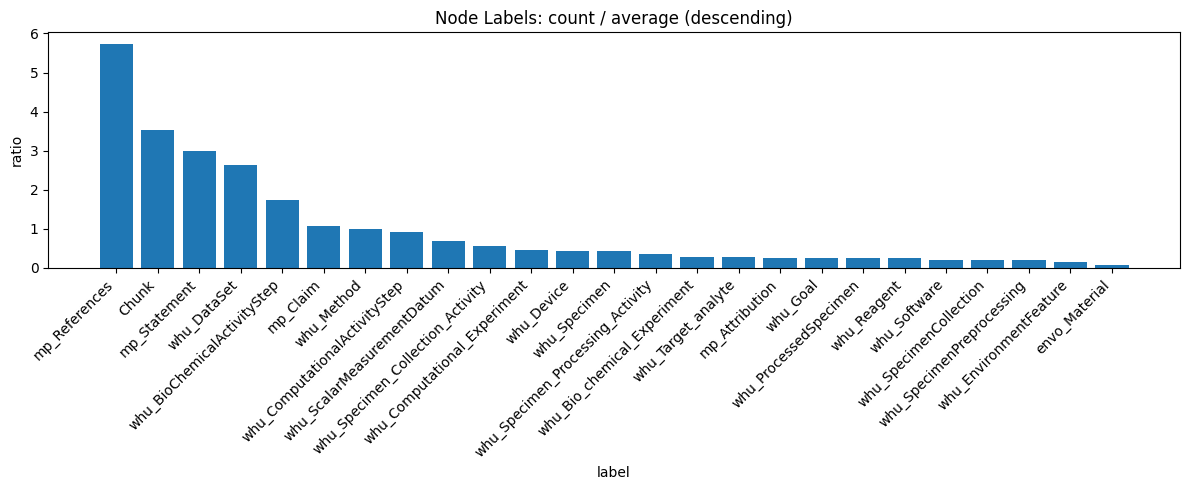

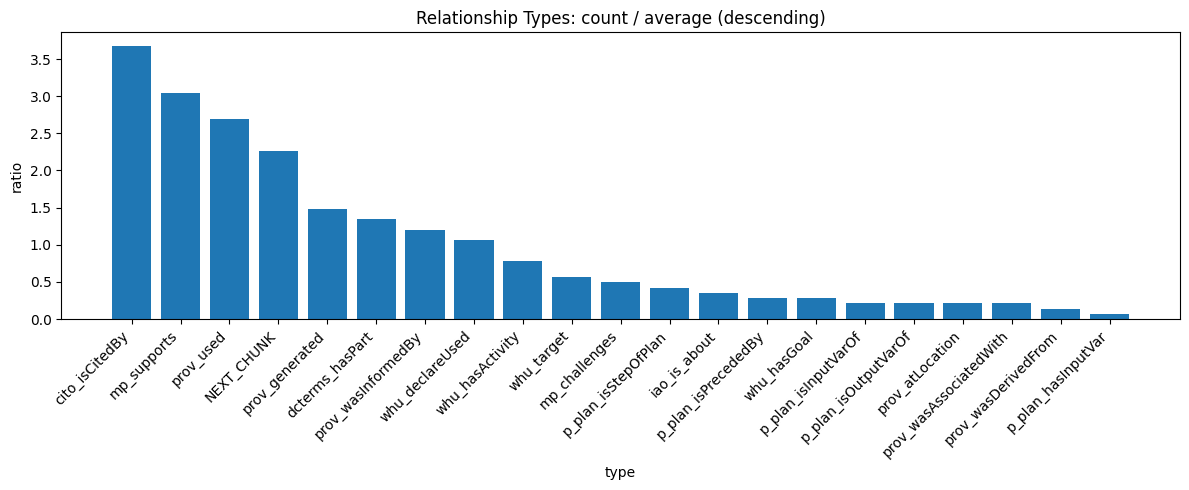

节点标签统计：
                               label  count    avg     ratio
0                      mp_References    161  28.04  5.741797
1                              Chunk     99  28.04  3.530670
2                       mp_Statement     84  28.04  2.995720
3                        whu_DataSet     74  28.04  2.639087
4        whu_BioChemicalActivityStep     49  28.04  1.747504
5                           mp_Claim     30  28.04  1.069900
6                         whu_Method     28  28.04  0.998573
7      whu_ComputationalActivityStep     26  28.04  0.927247
8         whu_ScalarMeasurementDatum     19  28.04  0.677603
9   whu_Specimen_Collection_Activity     16  28.04  0.570613
10      whu_Computational_Experiment     13  28.04  0.463623
11                        whu_Device     12  28.04  0.427960
12                      whu_Specimen     12  28.04  0.427960
13  whu_Specimen_Processing_Activity     10  28.04  0.356633
14       whu_Bio_chemical_Experiment      8  28.04  0.285307
15              

: 

In [ ]:
if __name__ == '__main__':
        # 假设已完成：
    # manager = utilities.return_llm_database.DatabaseManager(remotedatebase=False)
    # llm, embed_model, neo4j_driver = manager.get_components()

    # 直接调用
    import utilities.return_llm_database
    manager = utilities.return_llm_database.DatabaseManager(remotedatebase=False)
    _, _, neo4j_driver = manager.get_components()
    df_nodes, df_rels = analyze_kg_stats(
        neo4j_driver,
        exclude_labels=["__KGBuilder__", "__Entity__"],  # 可选：排除不关心的标签
        exclude_reltypes=["FROM_CHUNK"],                 # 可选：排除不关心的关系
        top_k=None,                            # 可选：仅看Top-K
        draw=True                              # 是否绘图
    )

    print("节点标签统计：")
    print(df_nodes)  # 包含：label, count, avg, ratio

    print("关系类型统计：")
    print(df_rels)   # 包含：type, count, avg, ratio